# Line segmentation

<>:114: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:114: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
C:\Users\WC\AppData\Local\Temp\ipykernel_8896\2081522415.py:114: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  diagnose_page("C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\processed\Buendia_Instruccion\croped_pages\Book1_page_0002_col_0.png")



📊 DIAGNOSTICS: Book1_page_0002_col_0.png
Image dimensions: (6000, 2813)
Brightness: 202.3/255
Contrast: 82.6

✅ Visualization saved: diagnostics_Book1_page_0002_col_0.png


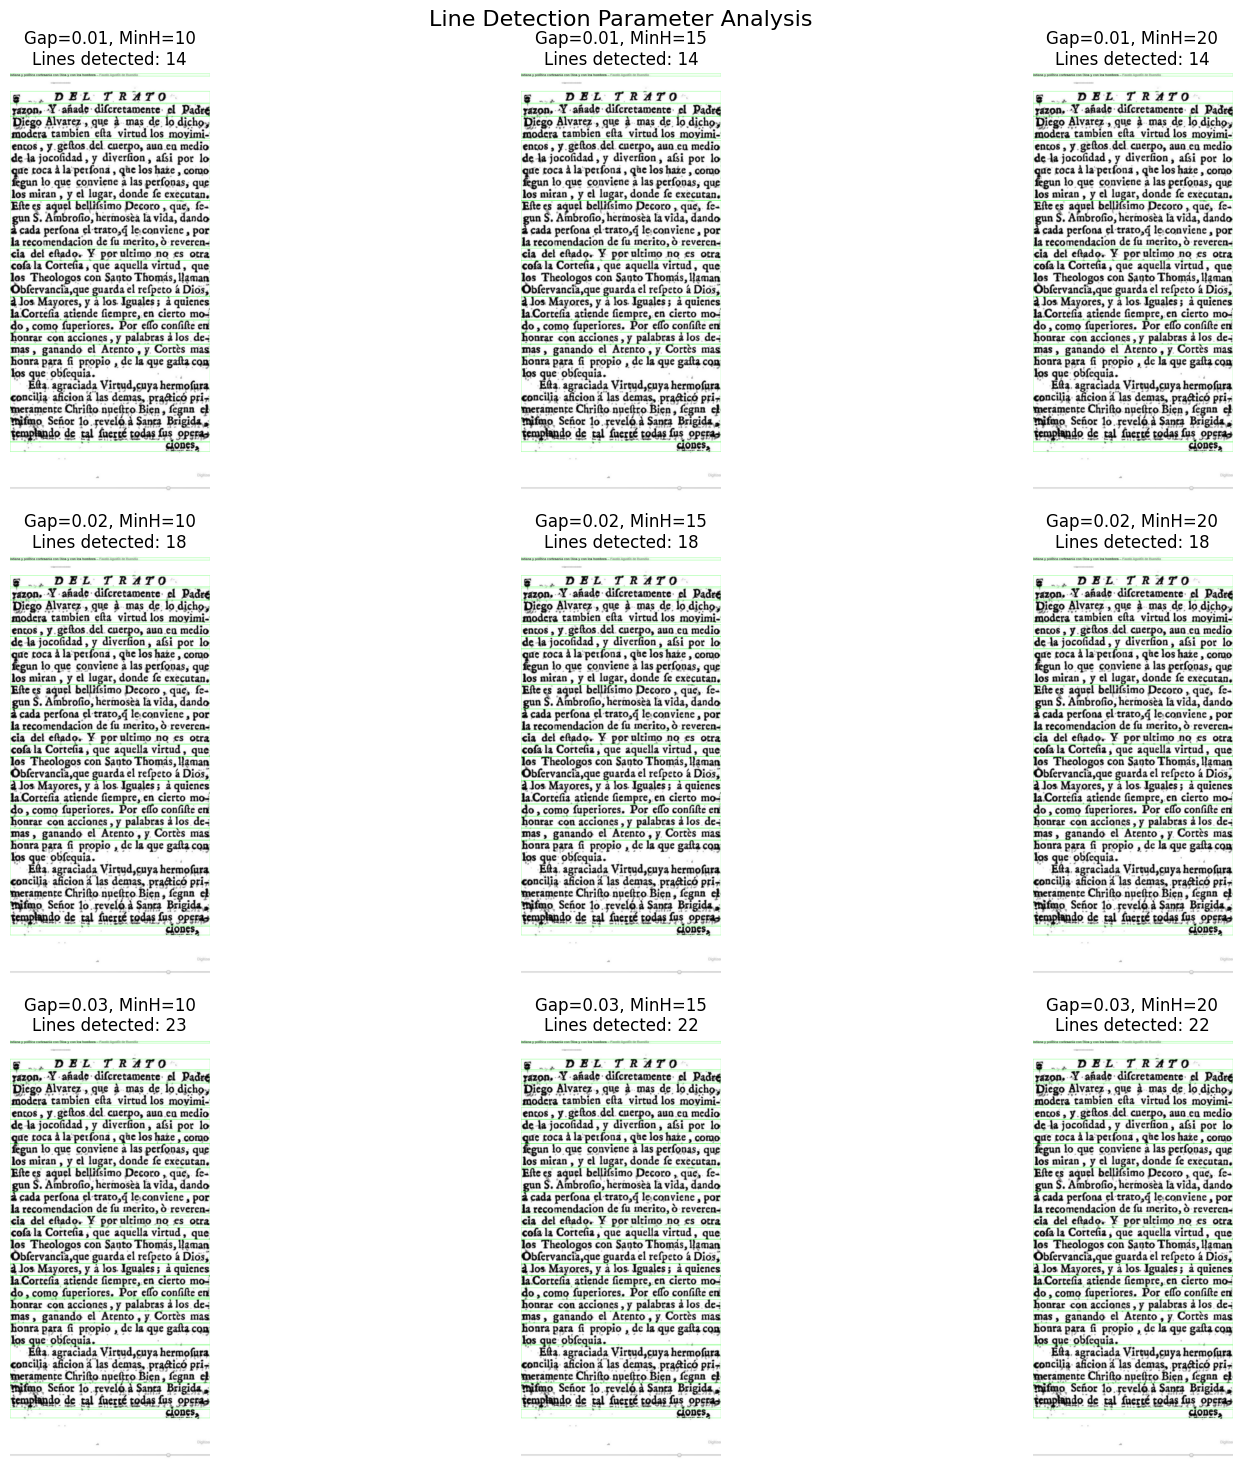

✅ Projection graph saved: projection_Book1_page_0002_col_0.png


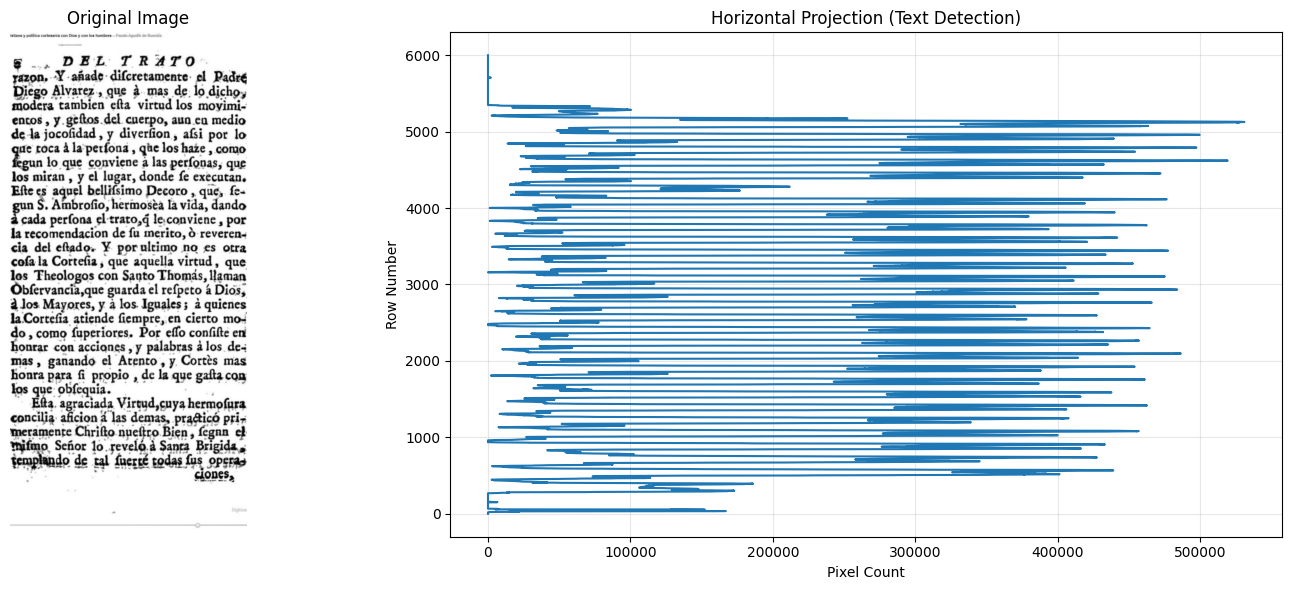

In [2]:


import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def diagnose_page(image_path, save_visualizations=True):
    """
    Visualize line detection process to find best parameters
    """
    
    # Load image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"❌ Cannot read: {image_path}")
        return
    
    print(f"\n📊 DIAGNOSTICS: {Path(image_path).name}")
    print(f"{'='*70}")
    print(f"Image dimensions: {img.shape}")
    print(f"Brightness: {np.mean(img):.1f}/255")
    print(f"Contrast: {np.std(img):.1f}")
    
    # ============ TEST DIFFERENT THRESHOLDS ============
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle('Line Detection Parameter Analysis', fontsize=16)
    
    gap_thresholds = [0.01, 0.02, 0.03]
    min_heights = [10, 15, 20]
    
    for idx_gap, gap_thresh in enumerate(gap_thresholds):
        for idx_height, min_height in enumerate(min_heights):
            ax = axes[idx_gap, idx_height]
            
            # Binarize
            _, binary = cv2.threshold(img, 0, 255, 
                                     cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            
            # Horizontal projection
            horizontal_sum = np.sum(binary, axis=1)
            
            # Threshold
            max_sum = np.max(horizontal_sum)
            threshold = gap_thresh * max_sum
            
            text_rows = np.where(horizontal_sum > threshold)[0]
            
            # Detect lines
            lines = []
            if len(text_rows) > 0:
                y_start = text_rows[0]
                y_prev = text_rows[0]
                
                for y in text_rows[1:]:
                    if y != y_prev + 1:
                        if y_prev - y_start >= min_height:
                            lines.append((y_start, y_prev))
                        y_start = y
                    y_prev = y
                
                if y_prev - y_start >= min_height:
                    lines.append((y_start, y_prev))
            
            # Visualize
            img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            
            for y1, y2 in lines:
                cv2.rectangle(img_rgb, (0, y1), (img.shape[1], y2), 
                            (0, 255, 0), 2)
            
            ax.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
            ax.set_title(f"Gap={gap_thresh}, MinH={min_height}\nLines detected: {len(lines)}")
            ax.axis('off')
    
    plt.tight_layout()
    output_path = f"diagnostics_{Path(image_path).stem}.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Visualization saved: {output_path}")
    plt.show()
    
    # ============ SHOW PROJECTION GRAPH ============
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Binarize
    _, binary = cv2.threshold(img, 0, 255, 
                             cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Horizontal projection
    horizontal_sum = np.sum(binary, axis=1)
    
    # Plot image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Plot projection
    axes[1].plot(horizontal_sum, range(len(horizontal_sum)))
    axes[1].set_title('Horizontal Projection (Text Detection)')
    axes[1].set_xlabel('Pixel Count')
    axes[1].set_ylabel('Row Number')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    projection_path = f"projection_{Path(image_path).stem}.png"
    plt.savefig(projection_path, dpi=150, bbox_inches='tight')
    print(f"✅ Projection graph saved: {projection_path}")
    plt.show()


# Run on your page
if __name__ == "__main__":
    diagnose_page("C:\Open Source\GSOC\org\HumanAI\gsoc-2026-renaissance-ocr-test\GSOC_2026_HumanAI_Test\data\processed\Buendia_Instruccion\croped_pages\Book1_page_0002_col_0.png")